Loading training dataset...
Classes found: ['.DS_Store', 'acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Class mapping: {'.DS_Store': 0, 'acai': 1, 'cupuacu': 2, 'graviola': 3, 'guarana': 4, 'pupunha': 5, 'tucuma': 6}

Training samples loaded: 90

Loading testing dataset...
Classes found: ['.DS_Store', 'acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Class mapping: {'.DS_Store': 0, 'acai': 1, 'cupuacu': 2, 'graviola': 3, 'guarana': 4, 'pupunha': 5, 'tucuma': 6}

Testing samples loaded: 30

Training set: (90, 128, 128, 3), Labels: (90, 7)
Testing set: (30, 128, 128, 3), Labels: (30, 7)
Number of classes: 7



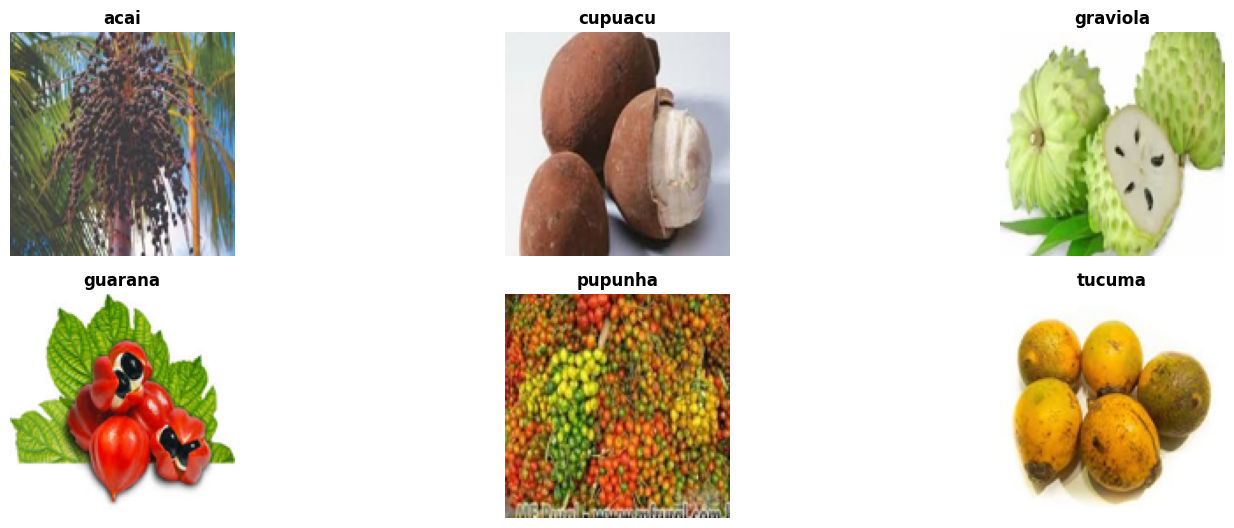

In [3]:
#Name: Shreetu Shrestha 
#ID: 2417729

import pandas as pd
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from PIL import Image  # Import Pillow

img_height, img_width = 128, 128  

train_dir = "/Users/shreetu/Documents/W5/FruitinAmazon/train"
test_dir = "/Users/shreetu/Documents/W5/FruitinAmazon/test"


def load_images_from_folder(folder):
    images = []
    labels = []
    class_names = sorted(os.listdir(folder))  
    class_map = {name: i for i, name in enumerate(class_names)}  # Map class names to labels
    
    print(f"Classes found: {class_names}")
    print(f"Class mapping: {class_map}\n")
    
    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label = class_map[class_name]
        
        if not os.path.isdir(class_path):
            continue
            
        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)
            
            try:
                # Load image using PIL
                img = Image.open(img_path).convert("RGB")  # Convert to RGB for color images
                img = img.resize((img_width, img_height))  # Resize to (128, 128)
                img = np.array(img) / 255.0  # Normalize pixel values to [0, 1]
                images.append(img)
                labels.append(label)
            except Exception as e:
                print(f"Error loading {img_path}: {e}")
                continue
    
    return np.array(images), np.array(labels), class_names

# Load training and testing datasets
print("Loading training dataset...")
x_train, y_train, class_names = load_images_from_folder(train_dir)
print(f"Training samples loaded: {len(x_train)}\n")

print("Loading testing dataset...")
x_test, y_test, _ = load_images_from_folder(test_dir)
print(f"Testing samples loaded: {len(x_test)}\n")

# Reshape images for Keras input (already in correct shape, but confirming)
x_train = x_train.reshape(-1, img_height, img_width, 3)  # Shape (num_samples, 128, 128, 3)
x_test = x_test.reshape(-1, img_height, img_width, 3)

# One-hot encode labels
num_classes = len(class_names)
y_train = to_categorical(y_train, num_classes=num_classes)
y_test = to_categorical(y_test, num_classes=num_classes)

# Print dataset shape
print(f"Training set: {x_train.shape}, Labels: {y_train.shape}")
print(f"Testing set: {x_test.shape}, Labels: {y_test.shape}")
print(f"Number of classes: {num_classes}\n")

# Visualize one image from each fruit class
plt.figure(figsize=(15, 8))

# Find one image from each class
class_indices = {}
for i, label in enumerate(y_train):
    label_idx = np.argmax(label)
    if label_idx not in class_indices:
        class_indices[label_idx] = i

# Display one image per class
num_cols = 3
num_rows = (num_classes + num_cols - 1) // num_cols

for idx, (label_idx, sample_idx) in enumerate(sorted(class_indices.items())):
    plt.subplot(num_rows, num_cols, idx + 1)
    plt.imshow(x_train[sample_idx])  # Display RGB image directly
    plt.title(f"{class_names[label_idx]}", fontsize=12, fontweight='bold')
    plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
import os
from PIL import Image

def check_and_remove_corrupted_images(train_dir):
    """
    Check for corrupted images in the dataset and remove them.
    
    Parameters:
    train_dir (str): Path to the train directory containing class subdirectories
    """
    
    corrupted_images = []
    total_images = 0
    valid_images = 0
    
    # Get all class directories
    class_directories = sorted([d for d in os.listdir(train_dir) 
                               if os.path.isdir(os.path.join(train_dir, d))])
    
    print(f"Scanning {len(class_directories)} classes for corrupted images...\n")
    print("=" * 70)
    
    # Iterate through each class subdirectory
    for class_name in class_directories:
        class_path = os.path.join(train_dir, class_name)
        print(f"\nChecking class: {class_name}")
        print("-" * 70)
        
        # Get all files in the class directory
        files = os.listdir(class_path)
        
        for filename in files:
            file_path = os.path.join(class_path, filename)
            
            # Skip if it's a directory
            if os.path.isdir(file_path):
                continue
            
            total_images += 1
            
            try:
                # Attempt to open and validate the image
                img = Image.open(file_path)
                img.verify()  # Verify the image is valid
                valid_images += 1
                
            except (IOError, OSError, Image.UnidentifiedImageError, SyntaxError) as e:
                # Image is corrupted
                corrupted_images.append(file_path)
                print(f"Removed corrupted image: {file_path}")
                
                try:
                    # Remove the corrupted image from the directory
                    os.remove(file_path)
                    print(f"  ✗ Successfully deleted from disk\n")
                except Exception as delete_error:
                    print(f"  ✗ Error deleting file: {delete_error}\n")
            
            except Exception as e:
                # Other unexpected errors
                print(f"  ✗ Unexpected error for {file_path}: {e}\n")
    
    # Print summary
    print("\n" + "=" * 70)
    print("SUMMARY REPORT")
    print(f"Total images scanned: {total_images}")
    print(f"Valid images: {valid_images}")
    print(f"Corrupted images found: {len(corrupted_images)}")
    
    # Final message
    if len(corrupted_images) == 0:
        print("\n✓ No Corrupted Images Found.")
    else:
        print(f"\n✗ Found and removed {len(corrupted_images)} corrupted image(s):")
        for img_path in corrupted_images:
            print(f"  - {img_path}")
    
    return corrupted_images


# Main execution
if __name__ == "__main__":
    train_dir = "/Users/shreetu/Documents/W5/FruitinAmazon/train"
    
    if os.path.exists(train_dir):
        print("\n")
        check_and_remove_corrupted_images(train_dir)
    else:
        print(f"Error: The path '{train_dir}' does not exist.")
        print("Please provide a valid path to the train directory.")



Scanning 6 classes for corrupted images...


Checking class: acai
----------------------------------------------------------------------

Checking class: cupuacu
----------------------------------------------------------------------

Checking class: graviola
----------------------------------------------------------------------

Checking class: guarana
----------------------------------------------------------------------

Checking class: pupunha
----------------------------------------------------------------------

Checking class: tucuma
----------------------------------------------------------------------

SUMMARY REPORT
Total images scanned: 90
Valid images: 90
Corrupted images found: 0

✓ No Corrupted Images Found.


Loading training dataset...
----------------------------------------------------------------------
Found 90 files belonging to 6 classes.
Using 72 files for training.
Training dataset created successfully!
Train dataset batches: 3
Batch size: 32

Loading validation dataset...
----------------------------------------------------------------------
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Validation dataset created successfully!
Validation dataset batches: 1

Loading test dataset...
----------------------------------------------------------------------
Found 30 files belonging to 6 classes.
Test dataset created successfully!
Test dataset batches: 1

DATASET SUMMARY
Number of classes: 7
Class names: ['.DS_Store', 'acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Image size: 128 x 128
Batch size: 32
Training batches: 3
Validation batches: 1
Test batches: 1

Visualizing one batch from training dataset...
----------------------------------------------

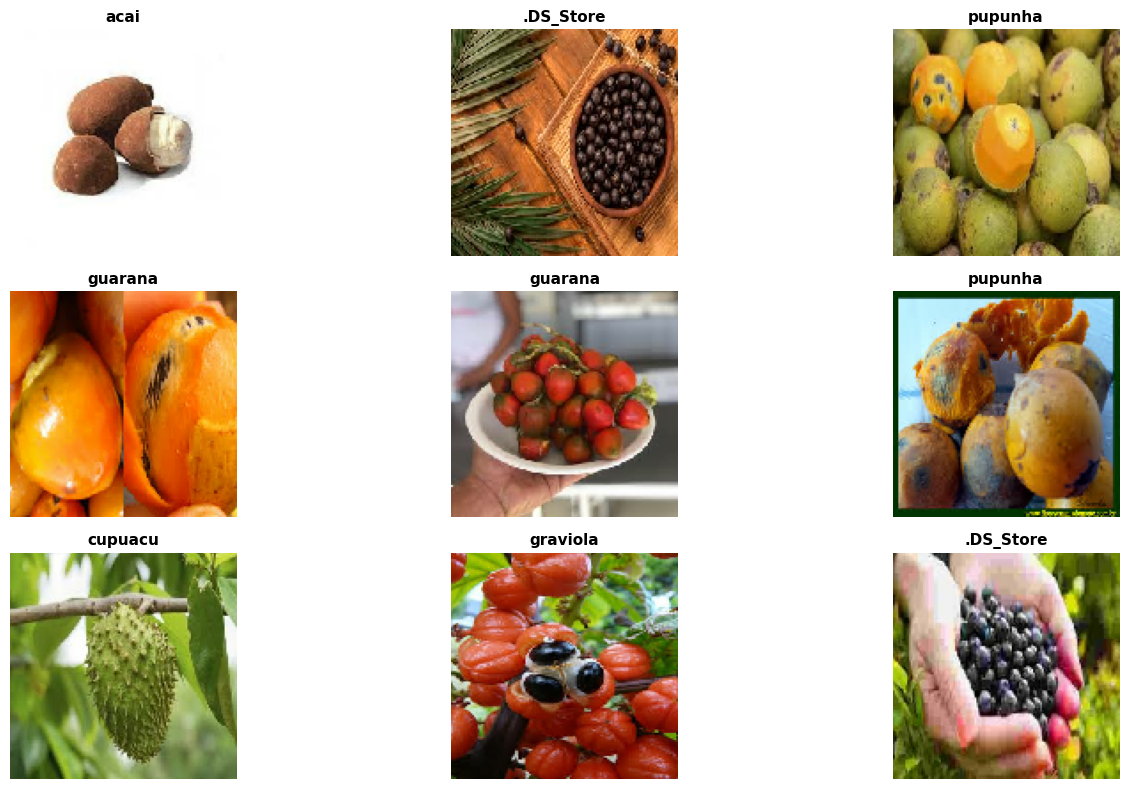


Datasets are ready for model training!


In [7]:
img_height = 128  # Image height
img_width = 128   # Image width
batch_size = 32
validation_split = 0.2  # 80% training, 20% validation

# Set the train directory
train_dir = "/Users/shreetu/Documents/W5/FruitinAmazon/train"
test_dir = "/Users/shreetu/Documents/W5/FruitinAmazon/test"

# Create a preprocessing layer for normalization
rescale = tf.keras.layers.Rescaling(1./255)  # Normalize pixel values to [0, 1]

print("Loading training dataset...")
print("-" * 70)

# Create training dataset with normalization
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

# Apply the normalization (Rescaling) to the dataset
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

print("Training dataset created successfully!")
print(f"Train dataset batches: {len(train_ds)}")
print(f"Batch size: {batch_size}")
print()

print("Loading validation dataset...")
print("-" * 70)

# Create validation dataset with normalization
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

# Apply the normalization (Rescaling) to the validation dataset
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

print("Validation dataset created successfully!")
print(f"Validation dataset batches: {len(val_ds)}")
print()

print("Loading test dataset...")
print("-" * 70)

# Create test dataset with normalization
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    seed=123
)

# Apply the normalization (Rescaling) to the test dataset
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

print("Test dataset created successfully!")
print(f"Test dataset batches: {len(test_ds)}")
print()

# Get class names
class_names = sorted(os.listdir(train_dir))
num_classes = len(class_names)

print("=" * 70)
print("DATASET SUMMARY")
print("=" * 70)
print(f"Number of classes: {num_classes}")
print(f"Class names: {class_names}")
print(f"Image size: {img_height} x {img_width}")
print(f"Batch size: {batch_size}")
print(f"Training batches: {len(train_ds)}")
print(f"Validation batches: {len(val_ds)}")
print(f"Test batches: {len(test_ds)}")
print("=" * 70)
print()

# Visualize a batch of images from training dataset
print("Visualizing one batch from training dataset...")
print("-" * 70)

plt.figure(figsize=(15, 8))

# Get one batch from training dataset
for images, labels in train_ds.take(1):
    # Display 9 images from the batch
    for i in range(min(9, len(images))):
        plt.subplot(3, 3, i + 1)
        
        # Convert normalized image back to [0, 255] for display
        img_display = (images[i].numpy() * 255).astype('uint8')
        plt.imshow(img_display)
        
        label_idx = labels[i].numpy()
        plt.title(f"{class_names[label_idx]}", fontsize=11, fontweight='bold')
        plt.axis('off')

plt.tight_layout()
plt.savefig('training_batch_samples.png', dpi=100, bbox_inches='tight')
print("✓ Batch visualization saved as 'training_batch_samples.png'")
plt.show()

print()
print("=" * 70)
print("Datasets are ready for model training!")
print("=" * 70)

In [8]:
from tensorflow import keras
from tensorflow.keras import layers, models

model = models.Sequential([
    # Convolutional Layer 1
    layers.Conv2D(filters=32, kernel_size=(3, 3), padding='same', 
                  strides=1, input_shape=(img_height, img_width, 3)),
    layers.Activation('relu'),
    
    # Max Pooling Layer 1
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),
    
    # Convolutional Layer 2
    layers.Conv2D(filters=32, kernel_size=(3, 3), padding='same', strides=1),
    layers.Activation('relu'),
    
    # Max Pooling Layer 2
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),
    
    # Flatten Layer
    layers.Flatten(),
    
    # Fully Connected Network
    layers.Dense(64, activation='relu'),      # Hidden Layer 1
    layers.Dense(128, activation='relu'),     # Hidden Layer 2
    layers.Dense(num_classes, activation='softmax')  # Output Layer
])
 
print("Model architecture created successfully!/n")
print("Model Summary:")

model.summary()

Model architecture created successfully!/n
Model Summary:


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,583 (8.07 MB)

 Trainable params: 2,116,583 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)
 
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,
    verbose=1,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    batch_size=16,
    callbacks=[checkpoint, early_stopping],
    verbose=1
)

Epoch 1/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.2109 - loss: 2.6329 
Epoch 1: val_loss improved from None to 2.64784, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - accuracy: 0.1944 - loss: 3.2371 - val_accuracy: 0.0000e+00 - val_loss: 2.6478
Epoch 2/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.1562 - loss: 2.0215
Epoch 2: val_loss improved from 2.64784 to 2.07588, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.1528 - loss: 2.0008 - val_accuracy: 0.0000e+00 - val_loss: 2.0759
Epoch 3/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.2031 - loss: 1.8189
Epoch 3: val_loss improved from 2.07588 to 1.94078, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.2639 - loss: 1.7989 - val_accuracy: 0.0000e+00 - val_loss: 1.9408
Epoch 4/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.2422 - loss: 1.7034
Epoch 4: val_loss improved from 1.94078 to 1.64621, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.2361 - loss: 1.6908 - val_accuracy: 0.4444 - val_loss: 1.6462
Epoch 5/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.3984 - loss: 1.5631
Epoch 5: val_loss improved from 1.64621 to 1.13637, saving model to best_model.h5


...


Epoch 15: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 1.0000 - loss: 0.0503 - val_accuracy: 0.9444 - val_loss: 0.3791
Epoch 16/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 1.0000 - loss: 0.0292
Epoch 16: val_loss improved from 0.37908 to 0.30721, saving model to best_model.h5



Epoch 16: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 1.0000 - loss: 0.0310 - val_accuracy: 0.8889 - val_loss: 0.3072
Epoch 17/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 1.0000 - loss: 0.0248
Epoch 17: val_loss did not improve from 0.30721
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 1.0000 - loss: 0.0230 - val_accuracy: 0.8333 - val_loss: 0.3597
Epoch 18/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 1.0000 - loss: 0.0097
Epoch 18: val_loss did not improve from 0.30721
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 1.0000 - loss: 0.0090 - val_accuracy: 0.8333 - val_loss: 0.5533
Epoch 19/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 1.0000 - loss: 0.0100
Epoch 19: val_loss did not improve from 0.30721
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 1.0000 - loss: 0.0111 - val_accuracy: 0.8333 - val_loss: 0.5834
Epoch 20/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 1.0000 - loss: 0.0062
Epoch 20: 


Epoch 22: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 1.0000 - loss: 0.0030 - val_accuracy: 0.8333 - val_loss: 0.3037
Epoch 23/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 1.0000 - loss: 0.0021
Epoch 23: val_loss improved from 0.30375 to 0.26246, saving model to best_model.h5



Epoch 23: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 1.0000 - loss: 0.0025 - val_accuracy: 0.8889 - val_loss: 0.2625
Epoch 24/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 1.0000 - loss: 0.0023
Epoch 24: val_loss improved from 0.26246 to 0.23786, saving model to best_model.h5



Epoch 24: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 1.0000 - loss: 0.0020 - val_accuracy: 0.8889 - val_loss: 0.2379
Epoch 25/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 1.0000 - loss: 0.0015
Epoch 25: val_loss did not improve from 0.23786
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 0.8889 - val_loss: 0.2403
Epoch 26/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 1.0000 - loss: 0.0014
Epoch 26: val_loss did not improve from 0.23786
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 1.0000 - loss: 0.0013 - val_accuracy: 0.8889 - val_loss: 0.2610
Epoch 27/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 1.0000 - loss: 0.0013
Epoch 27: val_loss did not improve from 0.23786
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 0.8889 - val_loss: 0.3026
Epoch 28/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 1.0000 - loss: 0.0010
Epoch 28: 

In [11]:
test_loss, test_accuracy = model.evaluate(test_ds, verbose=1)
 
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.7333 - loss: 0.8124
Test Loss: 0.8124
Test Accuracy: 0.7333 (73.33%)


In [12]:
model.save('trained_fruit_model.h5')
print("Model saved as 'trained_fruit_model.h5'")
 
# Load the saved model
loaded_model = keras.models.load_model('trained_fruit_model.h5')
print("Model loaded successfully!")
 
# Re-evaluate on test set
loaded_test_loss, loaded_test_accuracy = loaded_model.evaluate(test_ds, verbose=0)

Model saved as 'trained_fruit_model.h5'
Model loaded successfully!


In [14]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Collect predictions
# -----------------------------
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

# Convert to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# -----------------------------
# Debug info (optional but useful)
# -----------------------------
print("Unique classes in y_true:", np.unique(y_true))
print("Unique classes in y_pred:", np.unique(y_pred))
print("Total classes defined:", len(class_names))

# -----------------------------
# Classification Report (FIXED)
# -----------------------------
print("\nCLASSIFICATION REPORT:\n")

labels = np.arange(len(class_names))  # ensures all classes included

report = classification_report(
    y_true,
    y_pred,
    labels=labels,
    target_names=class_names,
    zero_division=0   # avoids warnings if a class is missing
)

print(report)

# -----------------------------
# Confusion Matrix
# -----------------------------
print("CONFUSION MATRIX:\n")

cm = confusion_matrix(y_true, y_pred, labels=labels)
print(cm)



Unique classes in y_true: [0 1 2 3 4 5]
Unique classes in y_pred: [0 1 2 3 4 5]
Total classes defined: 7

CLASSIFICATION REPORT:

              precision    recall  f1-score   support

   .DS_Store       0.60      0.60      0.60         5
        acai       0.45      1.00      0.62         5
     cupuacu       1.00      0.80      0.89         5
    graviola       1.00      0.60      0.75         5
     guarana       1.00      1.00      1.00         5
     pupunha       1.00      0.40      0.57         5
      tucuma       0.00      0.00      0.00         0

    accuracy                           0.73        30
   macro avg       0.72      0.63      0.63        30
weighted avg       0.84      0.73      0.74        30

CONFUSION MATRIX:

[[3 2 0 0 0 0 0]
 [0 5 0 0 0 0 0]
 [0 1 4 0 0 0 0]
 [1 1 0 3 0 0 0]
 [0 0 0 0 5 0 0]
 [1 2 0 0 0 2 0]
 [0 0 0 0 0 0 0]]
